## Chapter 3, P6: Partial Dependence Plots

While feature importance offers an overview of which features a GBM uses, these scores do not explain the **relationship between a feature & the model's predictions.** A Partial Dependence Plot (PDP) explains the following:
* Does an increase in a feature's value lead to a higher or lower prediction?
* Is the relationship between a feature and prediction linear, or more complex?

## Generating PDPs with Scikit-Learn

Let's begin by training a `GradientBoostingRegressor` on the California housing dataset.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Load and prepare data
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size = 0.2, random_state = 42
)
feature_names = housing.feature_names

# Train a GBM model
gbm = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)
gbm.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

## One-Way PDP

With a trained model, creating a PDP for a single feature like median income (`MedInc`) is straightforward.

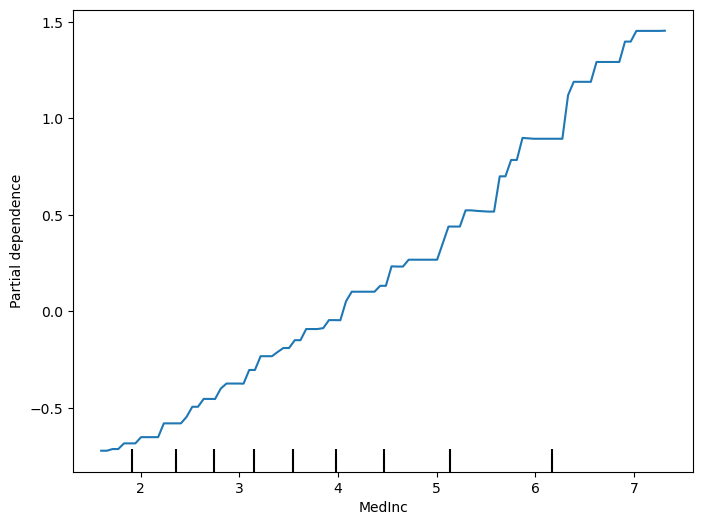

In [2]:
fig, ax = plt.subplots(figsize=(8,6))

PartialDependenceDisplay.from_estimator(
    gbm,
    X_train,
    features = ['MedInc'],
    feature_names = feature_names,
    ax = ax
)
plt.show()

**Interpreting One-Way PDP**

* Our GBM model has learned a posiitve, non-linear relationship between median income (feature) and house value (target). 
* The average predicted house value increases steadily as the median income rises, but the effect begins to level off for very high incomes.

This is a far more descriptive explanation than simply stating `MedInc` is an important feature.

## Two-Way PDP

By plotting **two features simultaneously**, we can **visualize their interaction effect on the prediction.**  

This helps answer questions like: "Does the effect of Feature A on the prediction depend on the value of Feature B?"

![heatmapPDP](../img/heatmap.png "Heatmap")

* The highest predicted house values occur in the the top-right corner, where both `MedInc` and `AveRooms` are large.
* An increase in the number of rooms has a stronger positive effect on price when median income is already high.

## Limitations

1. PDPs operate **under the assumption:** the features you're plotting are **not correlated with other features in the model** If two features are strongly correlated (e.g., age and years of experience), the process can create unrealistic data points and misleading plots.

2. PDPs show **the average effect across the entire dataset**. It can sometimes mask more complex relationships where a **feature affects diff. subsets of data in diff. ways**. For these scenarios, advanced techniques like **Individual Conditional Expectation (ICE)** plots can be used.

## Summary

Despite its limitations, PDPs are an indispensable tool for **interpreting GBMs**. They bridge the gap between knowing *what* features are important and understanding *how* these important features drive model predictions.  

This helps turn a complex model into a more transparent one.